# PINN para a Anomalia Gaussiana 

Nesse experimento será utilizado como modelo de velocidade um meio homogêneo com duas anomalias gaussianas, uma acima da média e outra abaixo da média de velocidade.

O modelo utilizado para a inversão sísmica será a PINN descrita no seguinte paper:

> RASHT-BEHESHT, Majid; HUBER, Christian; SHUKLA, Khemraj; KARNIADAKIS, George Em. \
**Physics-informed neural networks (PINNs) for wave propagation and full waveform inversions**. \
*Journal of Geophysical Research: Solid Earth*, v. 127, n. 5, e2021JB023120, 2022. DOI: 10.1029/2021JB023120.

### Bibliotecas

In [ ]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.quasirandom import SobolEngine
import matplotlib.pyplot as plt
import GPUtil
%matplotlib inline

import deepwave
from deepwave import scalar

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.set_default_dtype(torch.float64)

gpus = GPUtil.getGPUs()

for i, gpu in enumerate(gpus):
    print(f"GPU {i}: {gpu.name}")


Using device: cuda
GPU 0: NVIDIA RTX A4500


Os experimentos serão feitos com uma GPU NVIDIA RTX A4500, o tempo de execução desse experimento será relatado com base nessa placa gráfica.

### Carregando o modelo verdadeiro (`gaussian_anomaly.bin`)

modelo: (51, 101) min/max/mean: 1500.0 2500.0 2000.0000002843803


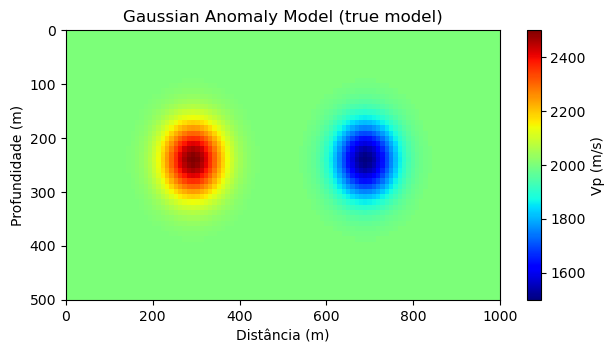

In [ ]:
MODEL_PATH = "/mnt/storage_C4/leticia_aleixo/piml-pub/proj-01/notebooks/gaussian_anomaly/gaussian_anomaly.bin"

NZ= 51
NY = 101
DZ = 10.0 # m
DY = 10.0 # m

raw = np.fromfile(MODEL_PATH, dtype="f4")
assert raw.size == NZ * NY, (
    f"Tamanho do binário ({raw.size} floats) não bate com NZ*NY ({NZ*NY}). "
    "Se você tiver o .hdr original, ajuste NZ/NY/DZ/DY acima."
)
model_np = raw.reshape([NZ, NY], order="F").astype(np.float64)  # (z, y), m/s
print("modelo:", model_np.shape, "min/max/mean:", model_np.min(), model_np.max(), model_np.mean())

plt.figure(figsize=(7, 3.5))
plt.imshow(model_np, cmap="jet", aspect="auto",
           extent=[0, (NY - 1) * DY, (NZ - 1) * DZ, 0])
plt.colorbar(label="Vp (m/s)")
plt.title("Gaussian Anomaly Model (true model)")
plt.xlabel("Distância (m)")
plt.ylabel("Profundidade (m)")
plt.show()

### Domínio físico e geometria de aquisição

In [ ]:
N_ABS = 10  # camada absorvente (PML) do deepwave, fica FORA do grid do modelo,
            # então todo o grid NY x NZ é fisicamente valido

ay_full = (NY - 1) * DY / 1000.0   # km, dominio fisico total em x (distancia)
az_full = (NZ - 1) * DZ / 1000.0   # km, dominio fisico total em z (profundidade)
print(f"Domínio físico do modelo (usado integralmente pela PINN): "
      f"{ay_full:.3f} km (dist.) x {az_full:.3f} km (prof.)")

Domínio físico do modelo (usado integralmente pela PINN): 1.000 km (dist.) x 0.500 km (prof.)


In [ ]:
DT = 0.004
NT_TOTAL = 200
PEAK_FREQ = 10.0
PEAK_TIME = 1.0 / PEAK_FREQ

t_st = 0.0
t_m = (NT_TOTAL - 1) * DT

N01, N02 = 40, 55
t01 = N01 * DT # instante do primeiro sismograma
t02 =  N02 * DT # instante do segundo sismograma
print(f"t01={t01:.3f}s  t02={t02:.3f}s  t_m={t_m:.3f}s")

t01=0.160s  t02=0.220s  t_m=0.796s


Foi considerada apenas uma fonte da onda acústica para esse experimento. 

O número de receptores foi 41, que formam uma linha horizontal na superfície.

In [ ]:
N_EVENT = 1 # uma unica fonte
N_RECEPT = 41 # linha horizontal de receptores

source_locations = torch.zeros(N_EVENT, 1, 2, dtype=torch.long, device=device)
source_locations[..., 0] = NY // 2 # fonte centralizada horizontalmente
source_locations[..., 1] = N_ABS + 1 # perto do topo

recv_x_idx = torch.linspace(N_ABS + 2, NY - N_ABS - 2, N_RECEPT).long()
receiver_locations = torch.zeros(N_EVENT, N_RECEPT, 2, dtype=torch.long, device=device)
receiver_locations[0, :, 0] = recv_x_idx
receiver_locations[0, :, 1] = N_ABS + 5 # profundidade fixa, um pouco abaixo da fonte

source_amplitudes = (
    deepwave.wavelets.ricker(PEAK_FREQ, NT_TOTAL, DT, PEAK_TIME)
    .repeat(N_EVENT, 1, 1)
    .to(device)
)

v_true = torch.tensor(model_np.T, device=device)  # deepwave espera (x, z)
print("v_true (deepwave):", v_true.shape)

v_true (deepwave): torch.Size([101, 51])


In [ ]:
V0 = 2.0 # km/s -- centro da faixa de velocidades do modelo (1.5-2.5 km/s)
L_char = V0 / PEAK_FREQ # km, comprimento de onda característico (=0.2 km)
T_char = 1.0 / PEAK_FREQ # s, período característico (=0.1 s)
print(f"L_char = {L_char:.4f} km   T_char = {T_char:.4f} s")

Lx, Lz = 1.0, 1.0

ax_nd = ay_full / L_char
az_nd = az_full / L_char
t_m_nd = (t_m - t_st) / T_char
print(f"Domínio adimensional da PINN: ax_nd={ax_nd:.3f}  az_nd={az_nd:.3f}  t_m_nd={t_m_nd:.3f}")

L_char = 0.2000 km   T_char = 0.1000 s
Domínio adimensional da PINN: ax_nd=5.000  az_nd=2.500  t_m_nd=7.960


### Gerando os dados sintéticos com `deepwave`

O modelo da PINN exige dois snapshots como condições iniciais e um sismograma em um instante posterior para ser utilizado na validação.

A geração desses dados foi feita com o deepwave.

#### Coordenadas adimensionais

Neste notebook, a modelagem é realizada utilizando **coordenadas adimensionais** (ou normalizadas), em vez de coordenadas físicas expressas em quilômetros e segundos. Essa transformação melhora o condicionamento numérico do problema e torna o treinamento da PINN mais estável.

#### Escalas características

São definidas três grandezas de referência:

$$
V_0 = 2.0\ \text{km/s}
$$
$$
T_{char} = \frac{1}{f_{peak}}
$$
$$
L_{char} = V_0T_{char}=\frac{V_0}{f_{peak}}
$$

onde:

- $V_0$ é uma velocidade de referência;
- $T_{char}$ é um tempo característico definido pela frequência dominante da fonte;
- $L_{char}$ é o comprimento característico, aproximadamente correspondente ao comprimento de onda associado à frequência dominante.

#### Transformação das coordenadas

As coordenadas físicas

$$
(x,z,t)
$$

são convertidas para coordenadas adimensionais por

$$
\xi=\frac{x}{L_{char}},~~
\zeta=\frac{z}{L_{char}},~~
\tau=\frac{t}{T_{char}}.
$$

Assim, a PINN nunca recebe diretamente valores em quilômetros ou segundos, mas sim as coordenadas normalizadas

$$
(\xi,\zeta,\tau).
$$

Após essa transformação, essas coordenadas ainda são reescaladas para o intervalo aproximadamente \([-1,1]\) antes de serem fornecidas às redes neurais, o que melhora o funcionamento das ativações do tipo `tanh`.

---

#### Equação da onda adimensional

A equação acústica utilizada é

$$
\frac{\partial^2 p}{\partial t^2}
=
v^2
\left(
\frac{\partial^2 p}{\partial x^2}
+
\frac{\partial^2 p}{\partial z^2}
\right).
$$

Aplicando a mudança de variáveis,

$$
x=L_{char}\xi,\qquad
z=L_{char}\zeta,\qquad
t=T_{char}\tau,
$$

as derivadas transformam-se segundo

$$
\frac{\partial}{\partial x} = \frac{1}{L_{char}} \frac{\partial}{\partial \xi},
$$

$$
\frac{\partial}{\partial t}
=
\frac{1}{T_{char}}
\frac{\partial}{\partial \tau}.
$$

Substituindo essas relações na equação da onda,

$$
\frac{1}{T_{char}^2}
\frac{\partial^2p}{\partial\tau^2}
=
v^2
\frac{1}{L_{char}^2}
\left(
\frac{\partial^2p}{\partial\xi^2}
+
\frac{\partial^2p}{\partial\zeta^2}
\right).
$$

Como

$$
L_{char}=V_0T_{char},
$$

obtém-se

$$
\frac{\partial^2p}{\partial\tau^2}
=
\left(\frac{v}{V_0}\right)^2
\left(
\frac{\partial^2p}{\partial\xi^2}
+
\frac{\partial^2p}{\partial\zeta^2}
\right).
$$

Define-se então a velocidade adimensional

$$
\alpha(\xi,\zeta)=\frac{v(x,z)}{V_0},
$$

resultando na forma final da PDE utilizada pela PINN:

$$
\boxed{
\frac{\partial^2p}{\partial\tau^2}
=
\alpha^2
\nabla^2p
}
$$

---

### Como a AlphaNet aprende

A rede **AlphaNet** não aprende diretamente o campo de velocidades físico \(v(x,z)\).

Seu objetivo é aproximar a função

$$
\alpha(\xi,\zeta)=\frac{v(x,z)}{V_0},
$$

ou seja, ela aprende a **velocidade relativa** em cada ponto do domínio.

Durante o treinamento:

- a entrada da AlphaNet são apenas as coordenadas adimensionais $(\xi,\zeta)$,

- a saída é um único escalar $\alpha(\xi,\zeta)$,

que representa a velocidade local normalizada.

Esse valor é utilizado diretamente na equação da onda, compondo o resíduo físico
$$
\mathcal{R}
=
\frac{\partial^2p}{\partial\tau^2}
-
\alpha^2
\nabla^2p.
$$
A AlphaNet **não recebe valores de velocidade como supervisão**. Seus parâmetros são ajustados de forma indireta: sempre que a velocidade prevista produz um campo de pressão incompatível com a equação da onda ou com os sismogramas observados, o erro é retropropagado para atualizar os pesos da rede.

Em outras palavras, a AlphaNet aprende o modelo de velocidades que melhor explica simultaneamente:

- a equação física;
- as condições iniciais e de contorno;
- os dados sísmicos observados.

In [7]:
def run_forward(nt, src_amp):
    return scalar(
        v_true, DY, DT,
        source_amplitudes=src_amp,
        source_locations=source_locations,
        receiver_locations=receiver_locations,
        accuracy=8,
        pml_freq=PEAK_FREQ,
        pml_width=N_ABS,
        max_vel=2500.0,
    )

out_full = run_forward(NT_TOTAL, source_amplitudes)
receiver_amplitudes = out_full[-1]

snap1_full = run_forward(N01, source_amplitudes[:, :, :N01])[0]
snap2_full = run_forward(N02, source_amplitudes[:, :, :N02])[0]

snap1 = snap1_full[0, N_ABS:-N_ABS, N_ABS:-N_ABS]
snap2 = snap2_full[0, N_ABS:-N_ABS, N_ABS:-N_ABS]

print("receiver_amplitudes:", receiver_amplitudes.shape)
print("snap1:", snap1.shape, " snap2:", snap2.shape)

receiver_amplitudes: torch.Size([1, 41, 200])
snap1: torch.Size([101, 51])  snap2: torch.Size([101, 51])


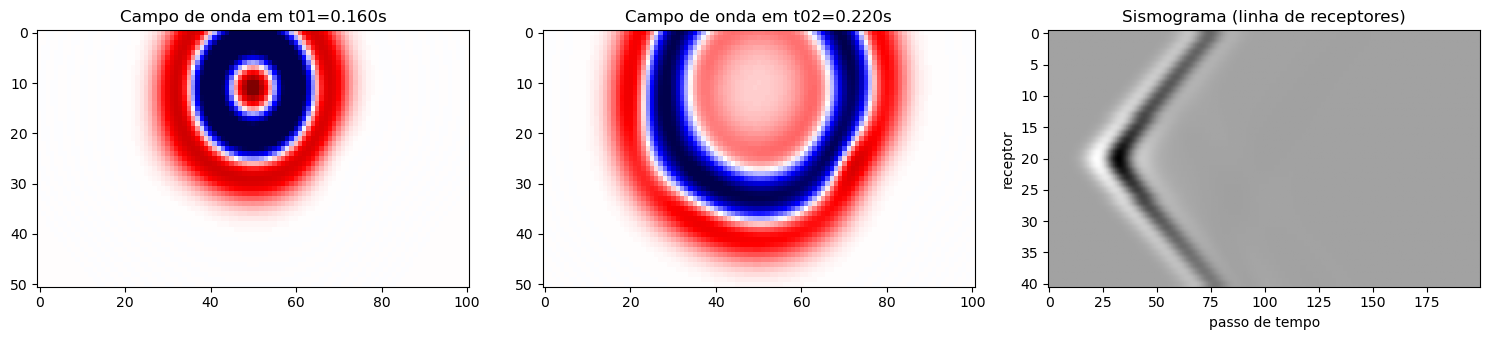

In [8]:
fig, ax_ = plt.subplots(1, 3, figsize=(15, 3.5))
vmax_snap = torch.quantile(snap2.abs(), 0.99).item()
ax_[0].imshow(snap1.detach().cpu().T, cmap="seismic", vmin=-vmax_snap, vmax=vmax_snap, aspect="auto")
ax_[0].set_title(f"Campo de onda em t01={t01:.3f}s")
ax_[1].imshow(snap2.detach().cpu().T, cmap="seismic", vmin=-vmax_snap, vmax=vmax_snap, aspect="auto")
ax_[1].set_title(f"Campo de onda em t02={t02:.3f}s")
im = ax_[2].imshow(receiver_amplitudes[0].detach().cpu(), cmap="gray", aspect="auto")
ax_[2].set_title("Sismograma (linha de receptores)")
ax_[2].set_xlabel("passo de tempo")
ax_[2].set_ylabel("receptor")
plt.tight_layout()
plt.show()

### Montando os pontos de treino, agora em coordenadas adimensionais `(ξ, ζ, τ)`

In [ ]:
def np2t(arr, requires_grad=False):
    return torch.tensor(arr, dtype=torch.float64, device=device, requires_grad=requires_grad)

n_ini_x, n_ini_z = snap1.shape

xx_np, zz_np = np.meshgrid(
    np.linspace(0, ax_nd, n_ini_x),
    np.linspace(0, az_nd, n_ini_z),
    indexing="ij",
)
xx0_np = xx_np.reshape(-1, 1)
zz0_np = zz_np.reshape(-1, 1)

X_init1_np = np.concatenate((xx0_np, zz0_np, 0.0 * np.ones_like(xx0_np)), axis=1)
X_init2_np = np.concatenate((xx0_np, zz0_np, ((t02 - t01) / T_char) * np.ones_like(xx0_np)), axis=1)

P_init1_np = snap1.detach().cpu().numpy().reshape(-1, 1)
P_init2_np = snap2.detach().cpu().numpy().reshape(-1, 1)

X_init1_t = np2t(X_init1_np, requires_grad=True)
X_init2_t = np2t(X_init2_np, requires_grad=True)
P_init1_t = np2t(P_init1_np)
P_init2_t = np2t(P_init2_np)

recv_x_phys_nd = recv_x_idx.numpy() * DY / 1000.0 / L_char
recv_z_phys_nd = (N_ABS + 5) * DZ / 1000.0 / L_char
t_vec_nd = (np.arange(NT_TOTAL) * DT - t01) / T_char

seis_rows, seis_targets = [], []
for r in range(N_RECEPT):
    tt = t_vec_nd.reshape(-1, 1)
    xx = np.full_like(tt, recv_x_phys_nd[r])
    zz = np.full_like(tt, recv_z_phys_nd)
    seis_rows.append(np.concatenate([xx, zz, tt], axis=1))
    seis_targets.append(receiver_amplitudes[0, r, :].detach().cpu().numpy().reshape(-1, 1))

X_S_np = np.concatenate(seis_rows, axis=0)
S_np = np.concatenate(seis_targets, axis=0)
l_sub = NT_TOTAL

X_S_t = np2t(X_S_np, requires_grad=True)
S_t = np2t(S_np)

print("X_init1:", X_init1_t.shape, " X_init2:", X_init2_t.shape)
print("X_S:", X_S_t.shape, " S:", S_t.shape)

X_init1: torch.Size([5151, 3])  X_init2: torch.Size([5151, 3])
X_S: torch.Size([8200, 3])  S: torch.Size([8200, 1])


### Redes: `PhiNet` (campo de onda) e `AlphaNet` (velocidade adimensional)

In [10]:
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

LAYERS_PHI = [3, 30, 30, 30, 1]
LAYERS_ALPHA = [2, 50, 50, 50, 50, 50, 1]

As hidden layers da `PhiNet`, `AlphaNet`, como feito no material de referência, são determinadas por:

Camada linear -> Função de ativação (Tanh)

In [11]:
class PhiNet(nn.Module):
    """
    Aproxima o campo de onda p(xi, zeta, tau) em coordenadas ADIMENSIONAIS
    (ver célula de adimensionalização acima). A normalização interna para
    tanh usa a extensão do domínio nessas mesmas unidades.
    """
    def __init__(self, layers_phi=LAYERS_PHI):
        super().__init__()
        hidden_layers = [
            layer for i in range(len(layers_phi) - 2)
            for layer in (nn.Linear(layers_phi[i], layers_phi[i+1]), nn.Tanh())
        ]
        output_layer = [nn.Linear(layers_phi[-2], layers_phi[-1])]
        self.net = nn.Sequential(*hidden_layers, *output_layer)
        self.apply(xavier_init)

        ub = torch.tensor([ax_nd, az_nd, t_m_nd], dtype=torch.float64).to(device)
        self.register_buffer("ub", ub)

    def forward(self, xzt):
        x_norm = (2.0 * xzt) / self.ub - 1.0
        return self.net(x_norm)

In [ ]:
class AlphaNet(nn.Module):
    """
    Aproxima a velocidade ADIMENSIONAL alpha_nd(xi, zeta) = alpha_km_s / V0.
    Para o modelo gaussiano (1.5-2.5 km/s) com V0=2.0 km/s, alpha_nd fica
    na faixa aproximada [0.75, 1.25] -> base=1.0, amp=0.25.
    """
    def __init__(self, layers_alpha=LAYERS_ALPHA, base=1.0, amp=0.25, lld=20.0):
        super().__init__()
        hidden_layers = [
            layer for i in range(len(layers_alpha) - 2)
            for layer in (nn.Linear(layers_alpha[i], layers_alpha[i+1]),
                          nn.Tanh())
        ]

        output_layer = [nn.Linear(layers_alpha[-2], layers_alpha[-1])]
        self.net = nn.Sequential(*hidden_layers, *output_layer)
        self.apply(xavier_init)

        ub0 = torch.tensor([ax_nd, az_nd], dtype=torch.float64).to(device)
        self.register_buffer("ub0", ub0)

        self.x_st, self.x_fi = 0.08 * ax_nd, 0.92 * ax_nd
        self.z_st, self.z_fi = 0.08 * az_nd, 0.92 * az_nd
        self.lld = lld   
        self.base = base
        self.amp = amp

    def _alpha_star(self, xz):
        x_n = (2.0 * xz) / self.ub0 - 1.0
        return torch.tanh(self.net(x_n))

    def _box_mask(self, xv, zv):
        mask = (
            0.5 * (1 + torch.tanh(self.lld * (xv - self.x_st))) *
            0.5 * (1 + torch.tanh(self.lld * (-xv + self.x_fi))) *
            0.5 * (1 + torch.tanh(self.lld * (zv - self.z_st))) *
            0.5 * (1 + torch.tanh(self.lld * (-zv + self.z_fi)))
        )
        return mask

    def forward(self, xv, zv):
        xz = torch.cat([xv, zv], dim=1)
        a_star = self._alpha_star(xz)
        mask = self._box_mask(xv, zv)
        return self.base + self.amp * a_star * mask

In [13]:
phi_net = PhiNet(LAYERS_PHI).to(device)
alpha_net = AlphaNet(LAYERS_ALPHA).to(device)
print(phi_net)
print(alpha_net)

PhiNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=1, bias=True)
  )
)
AlphaNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): Tanh()
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): Tanh()
    (10): Linear(in_features=50, out_features=1, bias=True)
  )
)


### Resíduo da PDE

In [ ]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs),
        create_graph=True, retain_graph=True)[0]


def pde_residual(xzt):
    """
    xzt = [xi, zeta, tau] (adimensional, requires_grad=True).
    Retorna p, p_tautau, P (laplaciano adimensional), alpha_nd e o resíduo eq.
    """
    x, z, t = xzt[:, 0:1], xzt[:, 1:2], xzt[:, 2:3]
    xzt_in = torch.cat([x, z, t], dim=1)

    p = phi_net(xzt_in)

    p_x = grad(p, x)
    p_xx = grad(p_x, x)
    p_z = grad(p, z)
    p_zz = grad(p_z, z)
    P = p_xx + p_zz

    p_t = grad(p, t)
    p_tt = grad(p_t, t)

    alpha_nd = alpha_net(x, z)
    eq = p_tt - alpha_nd ** 2 * P

    return {"p": p, "p_tt": p_tt, "P": P, "alpha": alpha_nd, "eq": eq}

### Pontos de colocação (Sobol) e função de perda

In [15]:
BATCH_SIZE_PDE = 20000
N_PDE_BATCHES = 500
n_pde = BATCH_SIZE_PDE * N_PDE_BATCHES

sobol = SobolEngine(dimension=3, scramble=True, seed=RANDOM_STATE)
X_pde_np = sobol.draw(n_pde).numpy()
X_pde_np[:, 0] *= ax_nd
X_pde_np[:, 1] *= az_nd
X_pde_np[:, 2] *= t_m_nd

print("X_pde:", X_pde_np.shape)

X_pde: (10000000, 3)


In [16]:
LAMBDA_PDE_TARGET = 1e-1
WARMUP_EPOCHS = 3000

def lambda_pde_at(epoch):
    return LAMBDA_PDE_TARGET * min(1.0, epoch / WARMUP_EPOCHS)


def compute_losses(X_pde_t, epoch):
    out_pde = pde_residual(X_pde_t)
    loss_pde = torch.mean(out_pde["eq"] ** 2)

    out_i1 = pde_residual(X_init1_t)
    loss_init1 = torch.mean((out_i1["p"] - P_init1_t) ** 2)

    out_i2 = pde_residual(X_init2_t)
    loss_init2 = torch.mean((out_i2["p"] - P_init2_t) ** 2)

    out_s = pde_residual(X_S_t)
    loss_seism = torch.mean((out_s["p"] - S_t) ** 2)

    lam = lambda_pde_at(epoch)
    total = lam * loss_pde + loss_init1 + loss_init2 + loss_seism

    return {
        "total": total, "pde": loss_pde,
        "init1": loss_init1, "init2": loss_init2, "seism": loss_seism,
        "lambda_pde": lam,
    }

### Loop de treinamento

In [17]:
NUM_EPOCHS = 200000
LEARNING_RATE = 1e-4
LOG_EVERY = 200
CHECKPOINT_PATH = "recorded_weights_gaussian_v4.pt"

optimizer = Adam(list(phi_net.parameters()) + list(alpha_net.parameters()), lr=LEARNING_RATE)

loss_rec = np.empty((0, 5))
bbn = 0

In [18]:
start = time.time()

for epoch in range(NUM_EPOCHS):
    X_pde_batch = X_pde_np[bbn * BATCH_SIZE_PDE:(bbn + 1) * BATCH_SIZE_PDE]
    X_pde_t = np2t(X_pde_batch, requires_grad=True)

    optimizer.zero_grad()
    losses = compute_losses(X_pde_t, epoch)
    losses["total"].backward()
    optimizer.step()

    if epoch % LOG_EVERY == 0:
        elapsed = time.time() - start
        print(
            f"Epoch {epoch:6d} | Time {elapsed:7.1f}s | lambda_pde {losses['lambda_pde']:.2e} | "
            f"Loss {losses['total'].item():.4e} | "
            f"PDE {losses['pde'].item():.4e} | "
            f"Init1 {losses['init1'].item():.4e} | "
            f"Init2 {losses['init2'].item():.4e} | "
            f"Seism {losses['seism'].item():.4e}"
        )
        loss_rec = np.concatenate((loss_rec, np.array([[
            epoch, losses["total"].item(), losses["pde"].item(),
            losses["init1"].item() + losses["init2"].item(), losses["seism"].item(),
        ]])), axis=0)

        bbn = (bbn + 1) % N_PDE_BATCHES

        torch.save({
            "phi_net": phi_net.state_dict(),
            "alpha_net": alpha_net.state_dict(),
            "loss_rec": loss_rec,
            "epoch": epoch,
        }, CHECKPOINT_PATH)

/home/al.leticia.ferreira/.local/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:408.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch      0 | Time     0.1s | lambda_pde 0.00e+00 | Loss 1.9532e+01 | PDE 3.5075e-02 | Init1 9.0508e+00 | Init2 6.7544e+00 | Seism 3.7269e+00
Epoch    200 | Time     8.2s | lambda_pde 6.67e-03 | Loss 1.8706e+01 | PDE 2.9396e-03 | Init1 8.5060e+00 | Init2 6.5213e+00 | Seism 3.6787e+00
Epoch    400 | Time    16.3s | lambda_pde 1.33e-02 | Loss 1.8664e+01 | PDE 4.5024e-03 | Init1 8.4688e+00 | Init2 6.5213e+00 | Seism 3.6737e+00
Epoch    600 | Time    24.5s | lambda_pde 2.00e-02 | Loss 1.8619e+01 | PDE 6.7886e-03 | Init1 8.4277e+00 | Init2 6.5130e+00 | Seism 3.6778e+00
Epoch    800 | Time    32.8s | lambda_pde 2.67e-02 | Loss 1.8541e+01 | PDE 1.8024e-02 | Init1 8.3550e+00 | Init2 6.4992e+00 | Seism 3.6859e+00
Epoch   1000 | Time    41.1s | lambda_pde 3.33e-02 | Loss 1.8425e+01 | PDE 5.8101e-02 | Init1 8.2283e+00 | Init2 6.4892e+00 | Seism 3.7059e+00
Epoch   1200 | Time    49.3s | lambda_pde 4.00e-02 | Loss 1.8312e+01 | PDE 1.7001e-01 | Init1 8.0507e+00 | Init2 6.5092e+00 | Seism 3.7455e+00

Tempo de execução: 
- 129 minutos para executar 200 mil épocas.

### Avaliação: velocidade invertida vs. modelo verdadeiro

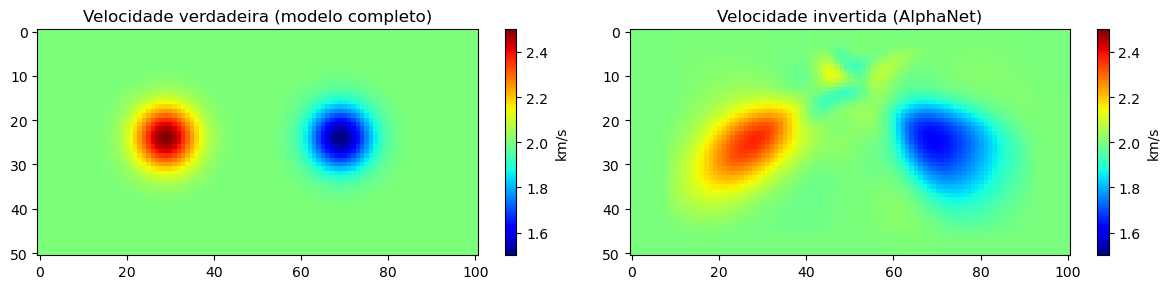

In [ ]:
phi_net.eval()
alpha_net.eval()

xx_eval, zz_eval = np.meshgrid(
    np.linspace(0, ax_nd, n_ini_x),
    np.linspace(0, az_nd, n_ini_z),
    indexing="ij",
)
xz_eval = np.concatenate([xx_eval.reshape(-1, 1), zz_eval.reshape(-1, 1)], axis=1)
xv_eval = np2t(xz_eval[:, 0:1], requires_grad=False)
zv_eval = np2t(xz_eval[:, 1:2], requires_grad=False)

with torch.no_grad():
    alpha_nd_pinn = alpha_net(xv_eval, zv_eval).cpu().numpy().reshape(n_ini_x, n_ini_z)
    alpha_pinn = alpha_nd_pinn * V0   # de volta para km/s

true_full = model_np.T / 1000.0

assert true_full.shape == alpha_pinn.shape, (true_full.shape, alpha_pinn.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
vmin, vmax = 1.5, 2.5
im0 = axes[0].imshow(true_full.T, cmap="jet", vmin=vmin, vmax=vmax, aspect="auto")
axes[0].set_title("Velocidade verdadeira (modelo completo)")
fig.colorbar(im0, ax=axes[0], label="km/s")

im1 = axes[1].imshow(alpha_pinn.T, cmap="jet", vmin=vmin, vmax=vmax, aspect="auto")
axes[1].set_title("Velocidade invertida (AlphaNet)")
fig.colorbar(im1, ax=axes[1], label="km/s")

plt.tight_layout()
plt.savefig("inverted_alpha_gaussian_v4.png", dpi=200)
plt.show()

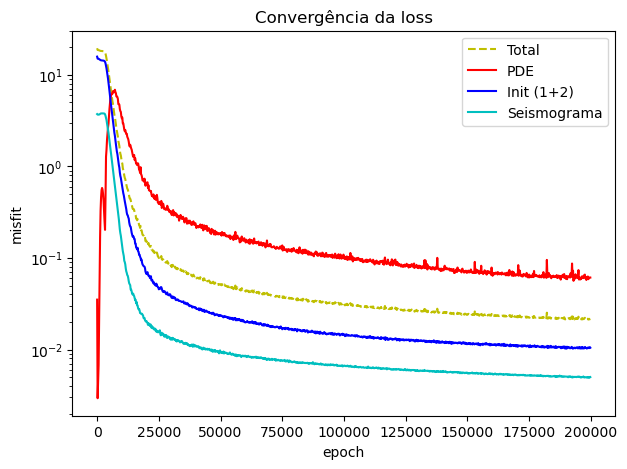

In [20]:
fig = plt.figure(figsize=(7, 5))
plt.plot(loss_rec[:, 0], loss_rec[:, 1], "--y", label="Total")
plt.plot(loss_rec[:, 0], loss_rec[:, 2], "r", label="PDE")
plt.plot(loss_rec[:, 0], loss_rec[:, 3], "b", label="Init (1+2)")
plt.plot(loss_rec[:, 0], loss_rec[:, 4], "c", label="Seismograma")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("misfit")
plt.legend()
plt.title("Convergência da loss")
plt.savefig("misfit_gaussian_v4.png", dpi=200)
plt.show()

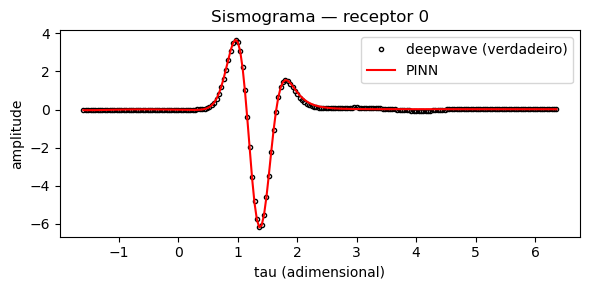

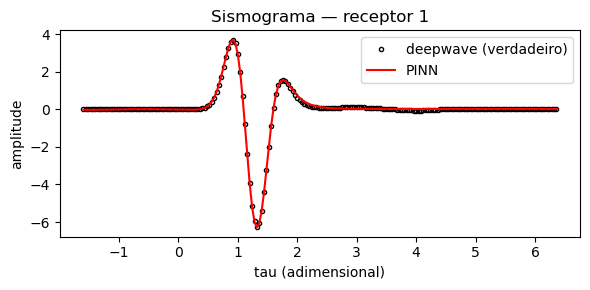

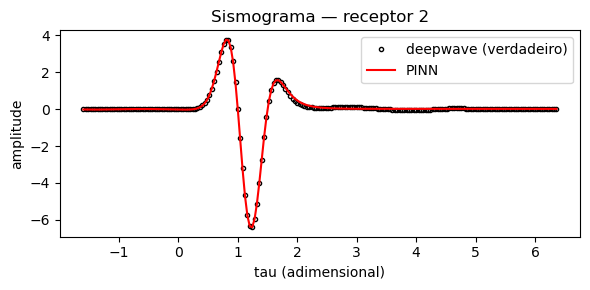

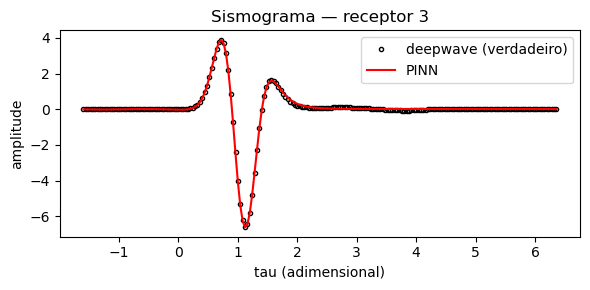

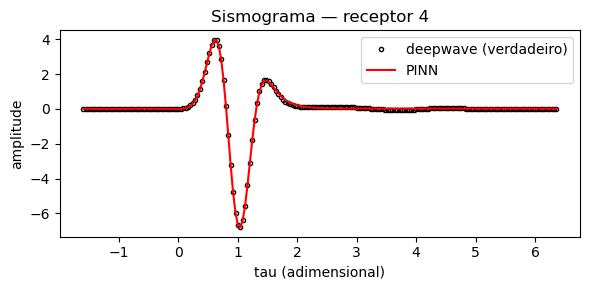

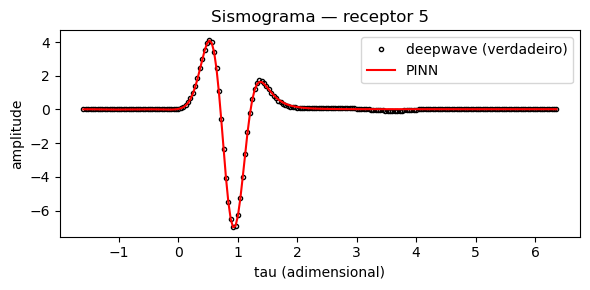

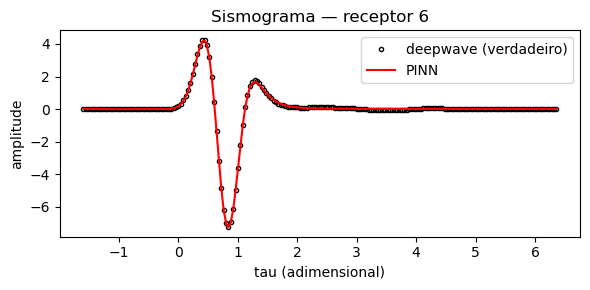

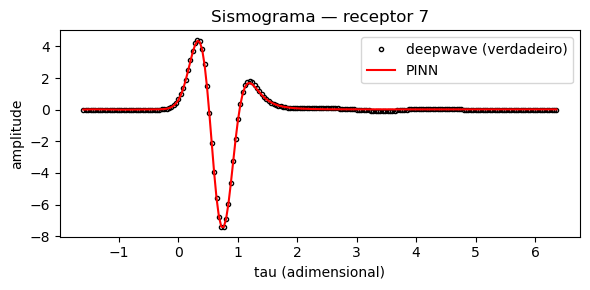

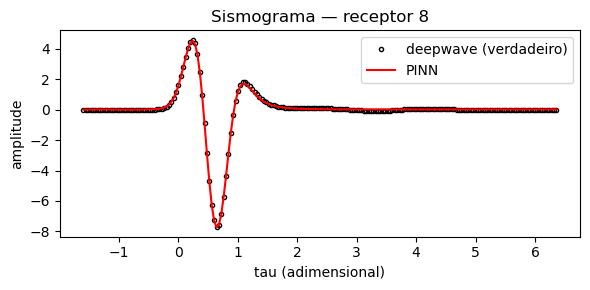

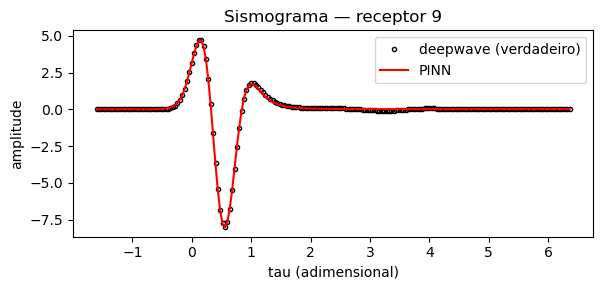

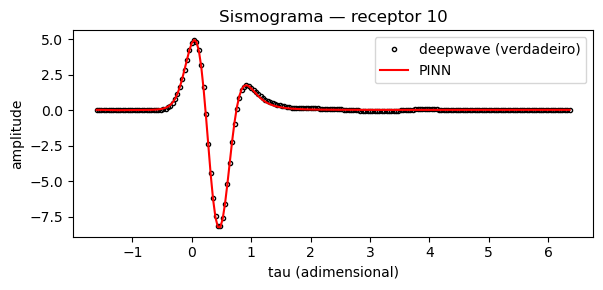

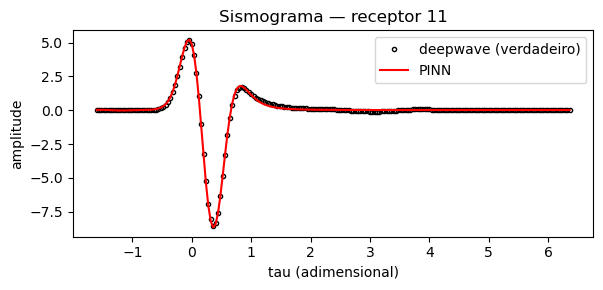

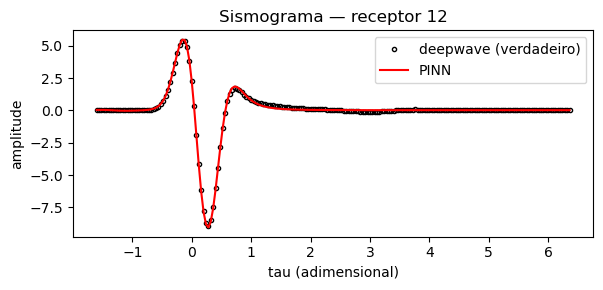

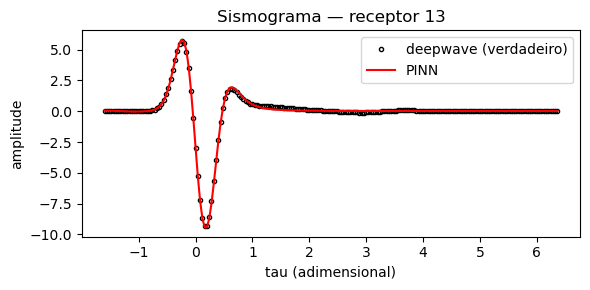

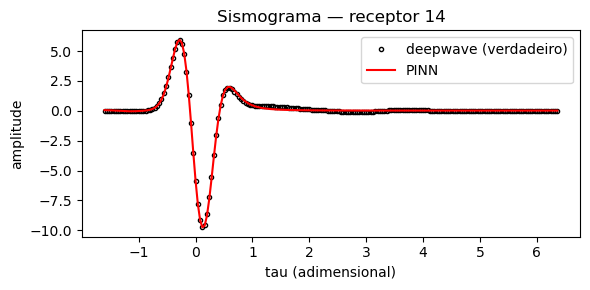

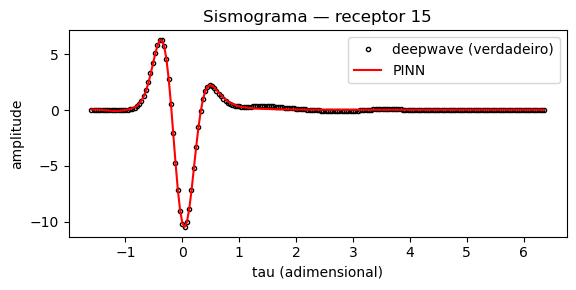

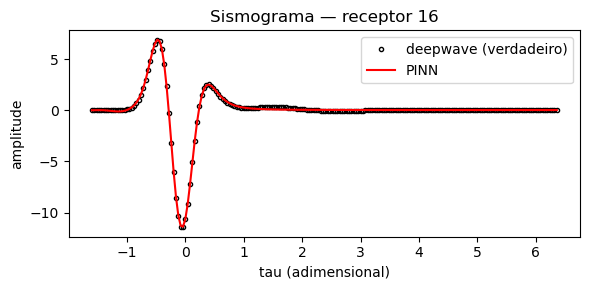

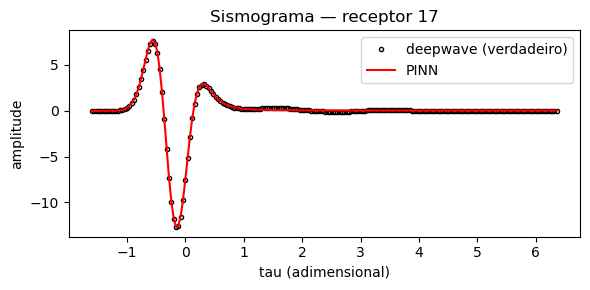

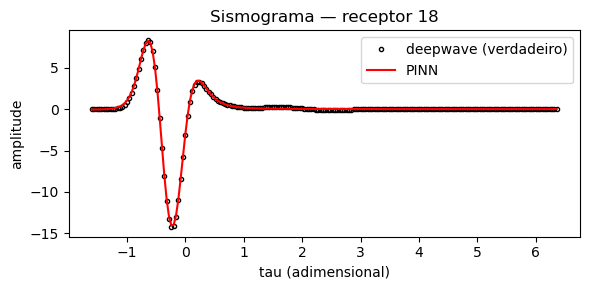

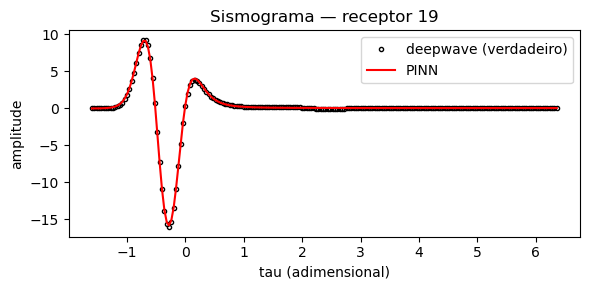

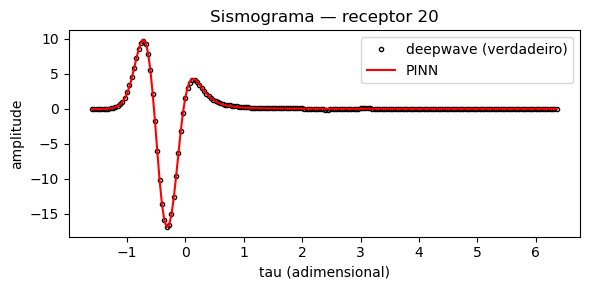

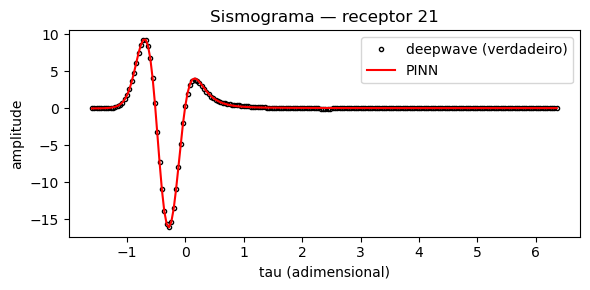

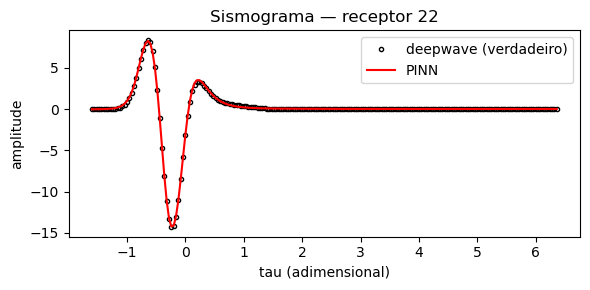

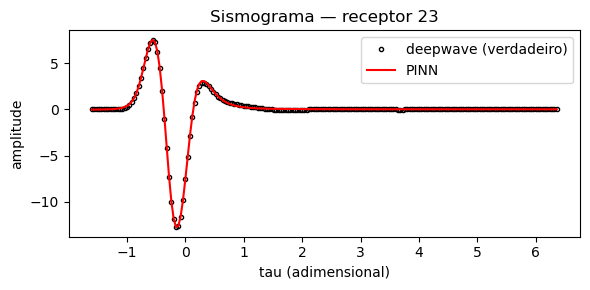

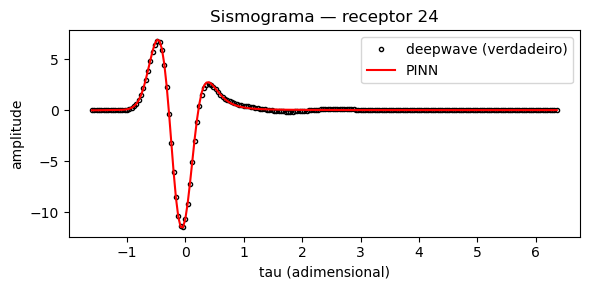

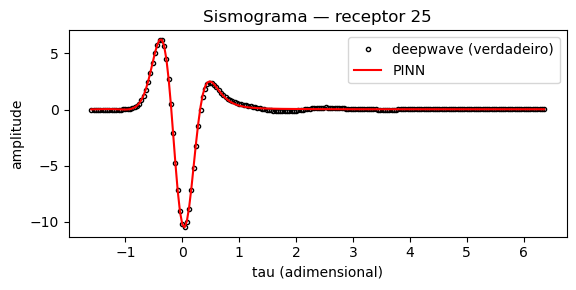

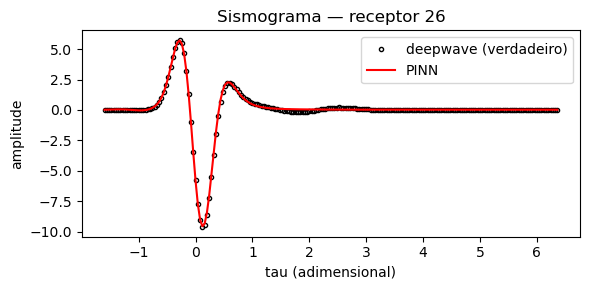

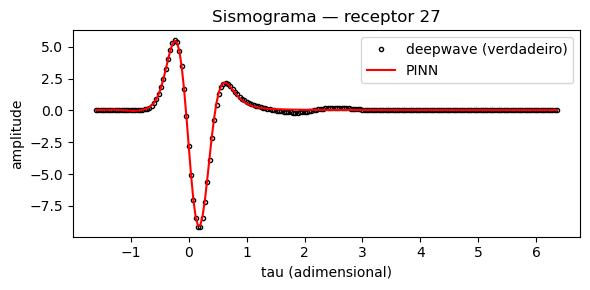

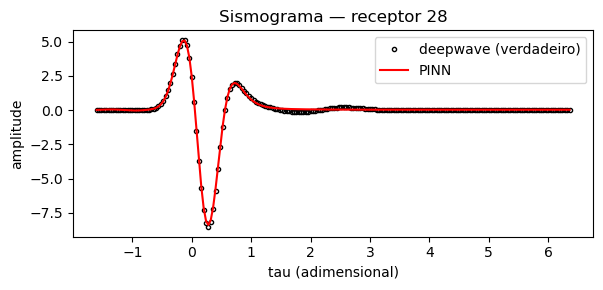

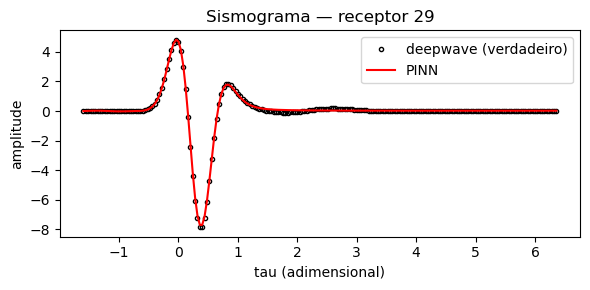

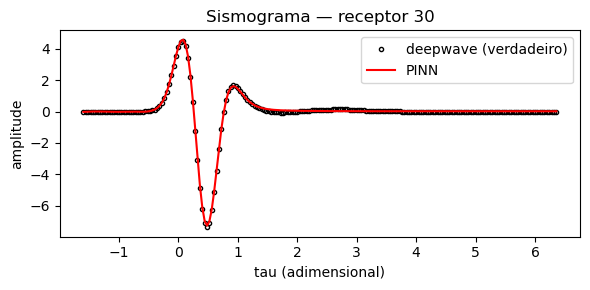

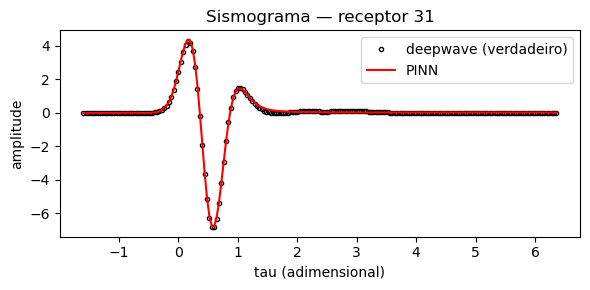

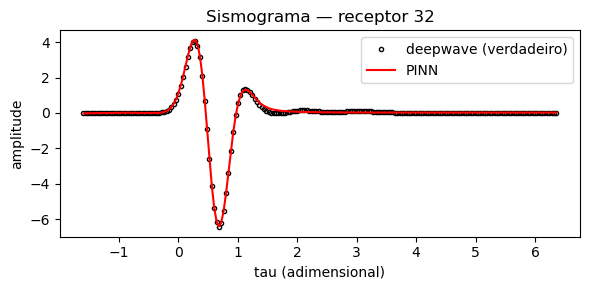

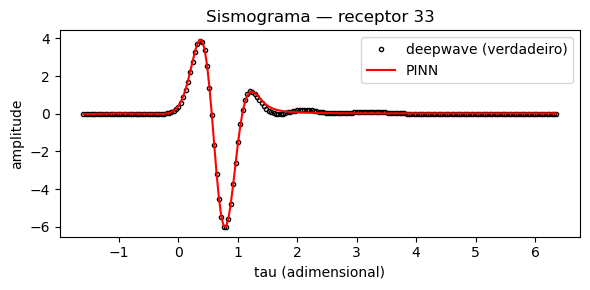

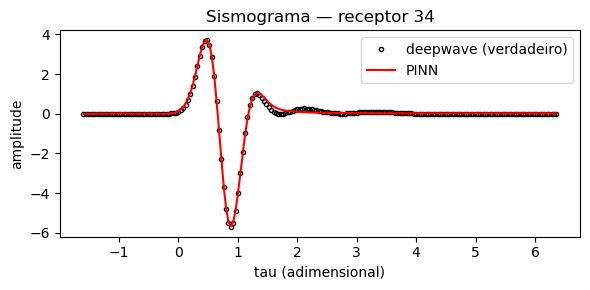

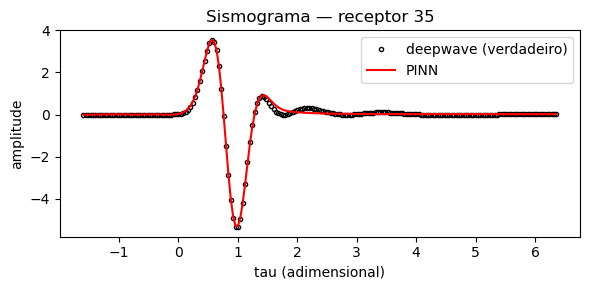

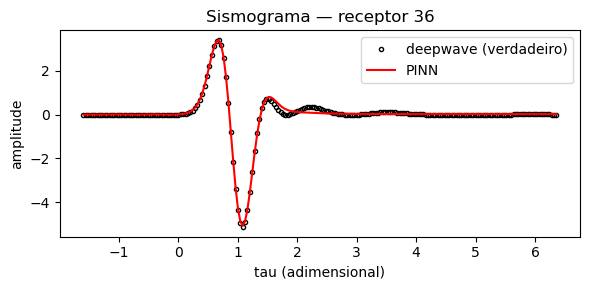

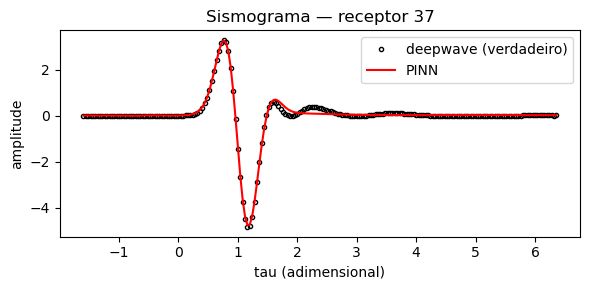

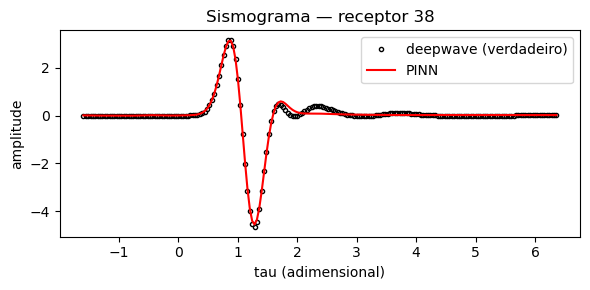

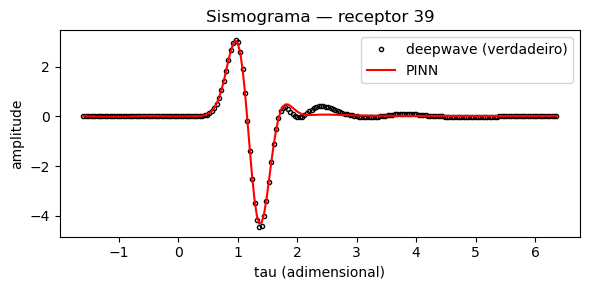

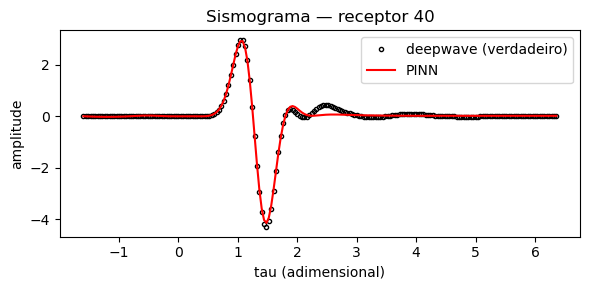

In [38]:
receiver_idx = 0

for i in range(N_RECEPT):
    sl = slice(receiver_idx * l_sub, (receiver_idx + 1) * l_sub)

    with torch.no_grad():
        p_pred = phi_net(X_S_t[sl]).cpu().numpy()

    plt.figure(figsize=(6, 3))
    plt.plot(X_S_np[sl, 2], S_np[sl], "ok", mfc="none", ms=3, label="deepwave (verdadeiro)")
    plt.plot(X_S_np[sl, 2], p_pred, "r", label="PINN")
    plt.xlabel("tau (adimensional)")
    plt.ylabel("amplitude")
    plt.title(f"Sismograma — receptor {receiver_idx}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("seismogram_compare_gaussian_v4.png", dpi=200)
    plt.show()

    receiver_idx += 1